In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv


# Titanic Survival Prediction

## Objective

The aim of this project is to predict whether a passenger survived the Titanic disaster using Machine Learning. I used Logistic Regression for this prediction because it is a simple and effective algorithm for binary classification problems.

In [2]:
# Importing required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# Reading the dataset

df = pd.read_csv("/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv")

# Display first five rows

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("Number of Rows and Columns :", df.shape)

df.info()

Number of Rows and Columns : (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# Checking missing values

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
# Filling missing values

df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin has many missing values, so removing it

df = df.drop("Cabin", axis=1)

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

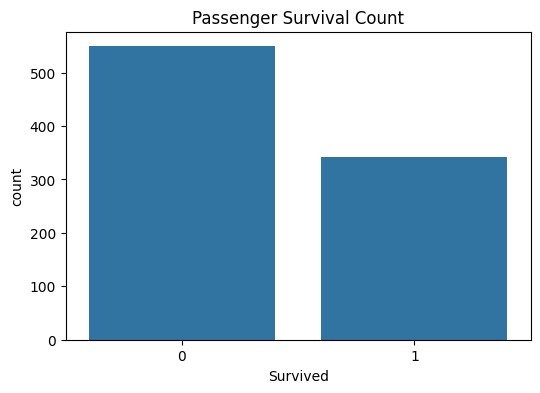

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Survived")

plt.title("Passenger Survival Count")

plt.show()

**Observation:** More passengers did not survive than survived.

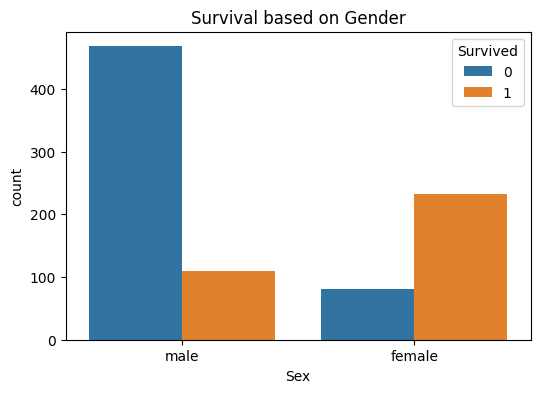

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival based on Gender")

plt.show()

**Observation:** Female passengers had a higher survival rate than male passengers.

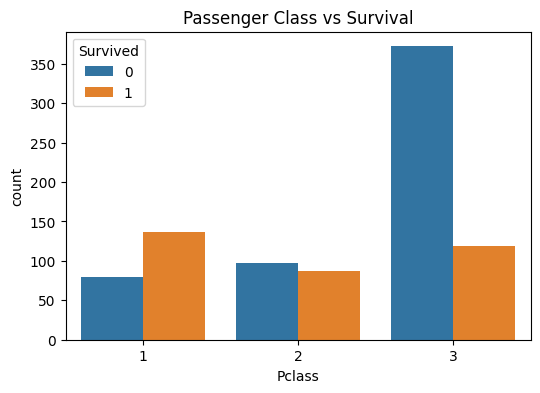

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Passenger Class vs Survival")

plt.show()

**Observation:** First-class passengers survived more often than third-class passengers.

In [10]:
encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])

df["Embarked"] = encoder.fit_transform(df["Embarked"])

In [11]:
# Removing unnecessary columns

df = df.drop(["PassengerId","Name","Ticket"], axis=1)

# Features

X = df.drop("Survived", axis=1)

# Target

y = df["Survived"]

In [12]:
# Splitting the data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=10
)

In [13]:
# Creating Logistic Regression model

model = LogisticRegression(max_iter=1000)

# Training the model

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [14]:
# Predicting test data

prediction = model.predict(X_test)

prediction[:10]

array([0, 0, 0, 1, 1, 0, 0, 0, 0, 0])

In [15]:
score = accuracy_score(y_test, prediction)

print("Model Accuracy :", round(score*100,2),"%")

Model Accuracy : 82.12 %


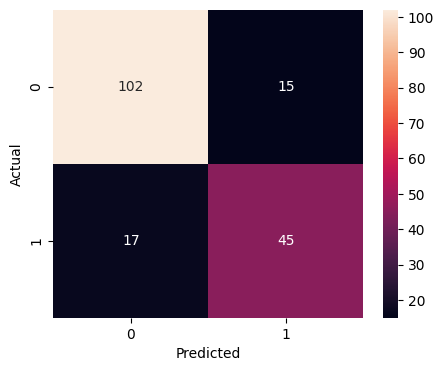

In [16]:
matrix = confusion_matrix(y_test, prediction)

plt.figure(figsize=(5,4))

sns.heatmap(matrix, annot=True, fmt="d")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [17]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.86      0.87      0.86       117
           1       0.75      0.73      0.74        62

    accuracy                           0.82       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179



## **Conclusion** 
In this project, I built a Logistic Regression model to predict Titanic passenger survival.

After cleaning the dataset and encoding categorical values, the model achieved good accuracy. The analysis showed that gender, passenger class, age, and fare were important factors affecting survival.

This project helped me understand the complete machine learning workflow, including data preprocessing, visualization, model training, and evaluation.